# **week3/ day 5**



In [13]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

df.fillna({'Age': df['Age'].median()}, inplace=True)
df.dropna(subset=['Embarked'], inplace=True)
df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
df['AgeGroup'] = df['Age'].apply(lambda x: 'Child' if x<13 else 'Teen' if x<18 else 'Adult' if x<61 else 'Senior')
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})

In [14]:
features = ['Pclass', 'Age', 'Fare', 'Sex_encoded']
X = df[features]
y = df['Survived']

•	Decision trees: information gain, Gini impurity - implement a 2-level tree from scratch

•	Train with Scikit-learn DecisionTreeClassifier - visualise with plot_tree

•	Depth 2 vs depth 10: observe overfitting, understand max_depth


1. Implement Gini impurity from scratch
2. Implement information gain from scratch
3. Build a 2-level decision tree manually using those functions
4. Train DecisionTreeClassifier on Titanic with sklearn
5. Visualise with plot_tree
6. Compare depth=2 vs depth=10 — accuracy + visual difference
7. Markdown cell: what does overfitting look like in a decision tree?

## 1. Gini impurity --> **Gini = 1 - Σ(p_i²)**

  

> 1. Gini impurity measures how mixed a node is !

> 2. A node with all one class = 0 (pure)

> 3. A node with 50/50 split = 0.5 (most impure)







  

In [15]:
import numpy as np
# 1. Implement Gini impurity from scratch
  # Gini = 1 - Σ(p_i²)

def gini_impurity(labels):
  p1 = np.mean(labels)
  p0 = 1- p1

  gini = 1 - (p0**2 + p1**2)
  return gini

In [16]:
a = np.array([0, 1, 1, 0, 1])
#np.mean(a)

gini_impurity(a)

np.float64(0.48)

In [17]:
gini_impurity(np.array([0,0,0,1,1,1]))

np.float64(0.5)

In [18]:
gini_impurity(np.array([0,0,0,0,0,0]))

np.float64(0.0)

## 2. Information gain
- Information gain measures how much a split reduces that impurity.

>  1. **Information Gain =  Gini(parent) - weighted average of Gini(left child) + Gini(right child)**




> 2. Perfect split = maximum gain.

> 3. Useless split = zero gain





In [19]:
#2. Implement information gain from scratch
def information_gain(parent, left, right):
  #1. gini_impurity oof parent node
  parent_gini = gini_impurity(parent)

  #2. wEIGHTED gini of children
  left_gini = gini_impurity(left)
  right_gini = gini_impurity(right)

  weighted_avg = (len(left)/len(parent)) * left_gini + (len(right)/len(parent)) * right_gini

  #parent - weighted children
  return parent_gini - weighted_avg


In [20]:
# 50/50 split, Gini = 0.5
parent = np.array([0,0,0,1,1,1])

left_perfect  = np.array([0,0,0])
right_perfect = np.array([1,1,1])

print(information_gain(parent, left_perfect, right_perfect))
#Perfect split = maximum gain.

0.5


In [21]:
left_useless  = np.array([0,1])
right_useless = np.array([0,0,1,1])

print(information_gain(parent, left_useless, right_useless))
# Useless split = zero gain

0.0


### 3. Build a 2-level decision tree manually using those functions

1. gini_impurity()        
      ↓
2. information_gain()      
      ↓
3. information_gain_split()(helper that splits data and calls information_gain)
  -   ↓
4. best_split()            ← tries ALL features/thresholds, finds best one
  -   ↓
5. build_tree()            ← recursively calls best_split to grow the tree

In [22]:
# 3. Build a 2-level decision tree manually using those functions

# A function that tries one feature and one threshold and returns the information gain

def information_gain_split(X,y, feature, threshold):
    # split data into left and right based on threshold
    left = y[X[:,feature] <= threshold]
    right = y[X[:, feature] > threshold]

    #if either side is empty return 0
    if len(left) == 0 or len(right) == 0:
      return 0

    return information_gain(y,left,right)

In [25]:
#Titanic X and y, feature index 0 (Pclass), threshold 2.

X_array = X.values
y_array = y.values

information_gain_split(X=X_array,y=y_array,feature=0,threshold=2)

np.float64(0.048421766366174124)

In [28]:
# tries ALL features/thresholds, finds best one

def best_split(X,y):
  best_gain = 0
  best_feature = None
  best_threshold = None

  for feature in range(X.shape[1]):
    thresholds = np.unique(X[:, feature])   #Pclass -> (1,2,3)

    for threshold in thresholds:
      gain = information_gain_split(X,y,feature,threshold)
      if gain > best_gain:
        best_gain = gain
        best_feature = feature
        best_threshold = threshold
  return best_feature,best_threshold


In [29]:
best_feature, best_threshold = best_split(X_array, y_array)
print(f"Best feature: {best_feature}, Best threshold: {best_threshold}")

Best feature: 3, Best threshold: 0.0


In [30]:
def build_tree(X, y, depth=0, max_depth=2):
    # if depth == max_depth or pure node → return majority class
    if depth == max_depth or len(np.unique(y)) == 1:
      return np.argmax(np.bincount(y))

    #SPLIT THE DATA
    #filter X,y into left, right
    best_feature, best_threshold = best_split(X, y)

    #filter X and y into left and right subsets using feature and threshold
    left_mask = X[:, best_feature] <= best_threshold
    X_left, y_left = X[left_mask], y[left_mask]
    X_right, y_right = X[~left_mask], y[~left_mask]


    # otherwise → find best split, recurse on left and right
    return {
    'feature': best_feature,
    'threshold': best_threshold,
    'left': build_tree(X_left, y_left, depth+1, max_depth),  # recursive call on left data
    'right': build_tree(X_right, y_right, depth+1, max_depth)# recursive call on right data
}

In [31]:
tree = build_tree(X_array, y_array, max_depth=2)
print(tree)

{'feature': 3, 'threshold': np.float64(0.0), 'left': {'feature': 1, 'threshold': np.float64(6.0), 'left': np.int64(1), 'right': np.int64(0)}, 'right': {'feature': 0, 'threshold': np.float64(2.0), 'left': np.int64(1), 'right': np.int64(0)}}


1. Root (Level 0): Split on feature 3 (Sex_encoded) at 0.0

- Males (<=0) → go left
- Females (>0) → go right

2. Left branch — Males (Level 1): Split on feature 1 (Age) at 6.0

- Males under 6 → predict 1 (survived) — young boys prioritised
- Males over 6 → predict 0 (died)

3. Right branch — Females (Level 1): Split on feature 0 (Pclass) at 2.0

- Females in class 1/2 → predict 1 (survived)
- Females in class 3 → predict 0 (died

### 4. Train DecisionTreeClassifier on Titanic with sklearn


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [34]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

#depth =2
clf_d2 = DecisionTreeClassifier(max_depth=2, random_state=42)

#fit
clf_d2.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [38]:
#predict
y_pred = clf_d2.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Accuracy: 0.80


In [39]:
#depth = 10
clf_d10 = DecisionTreeClassifier(max_depth=10, random_state=42)
clf_d10.fit(X_train,y_train)
y_pred = clf_d10.predict(X_test)
print(f"Accuracy score: {accuracy_score(y_test,y_pred):.2f}")

Accuracy score: 0.78


5. Visualise with plot_tree
6. Compare depth=2 vs depth=10 — accuracy + visual difference


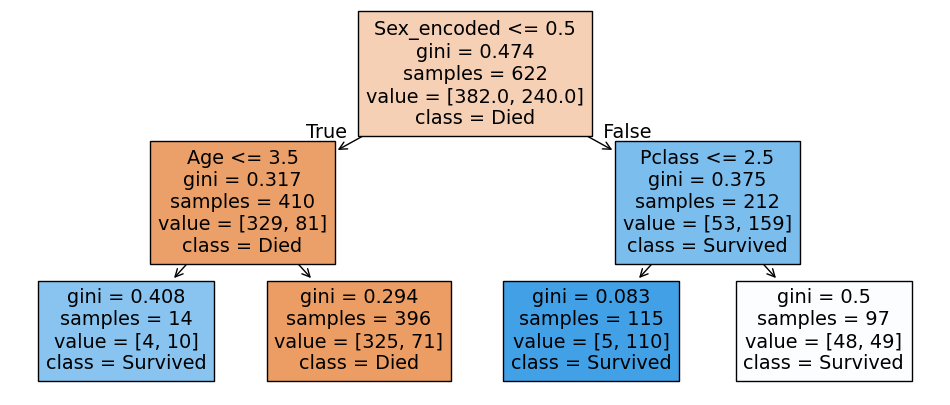

In [40]:
import matplotlib.pyplot as plt

#depth =2
fig,ax = plt.subplots(figsize=(12,5))
plot_tree(clf_d2,feature_names=features, class_names=['Died', 'Survived'], filled=True, ax=ax)
plt.show()

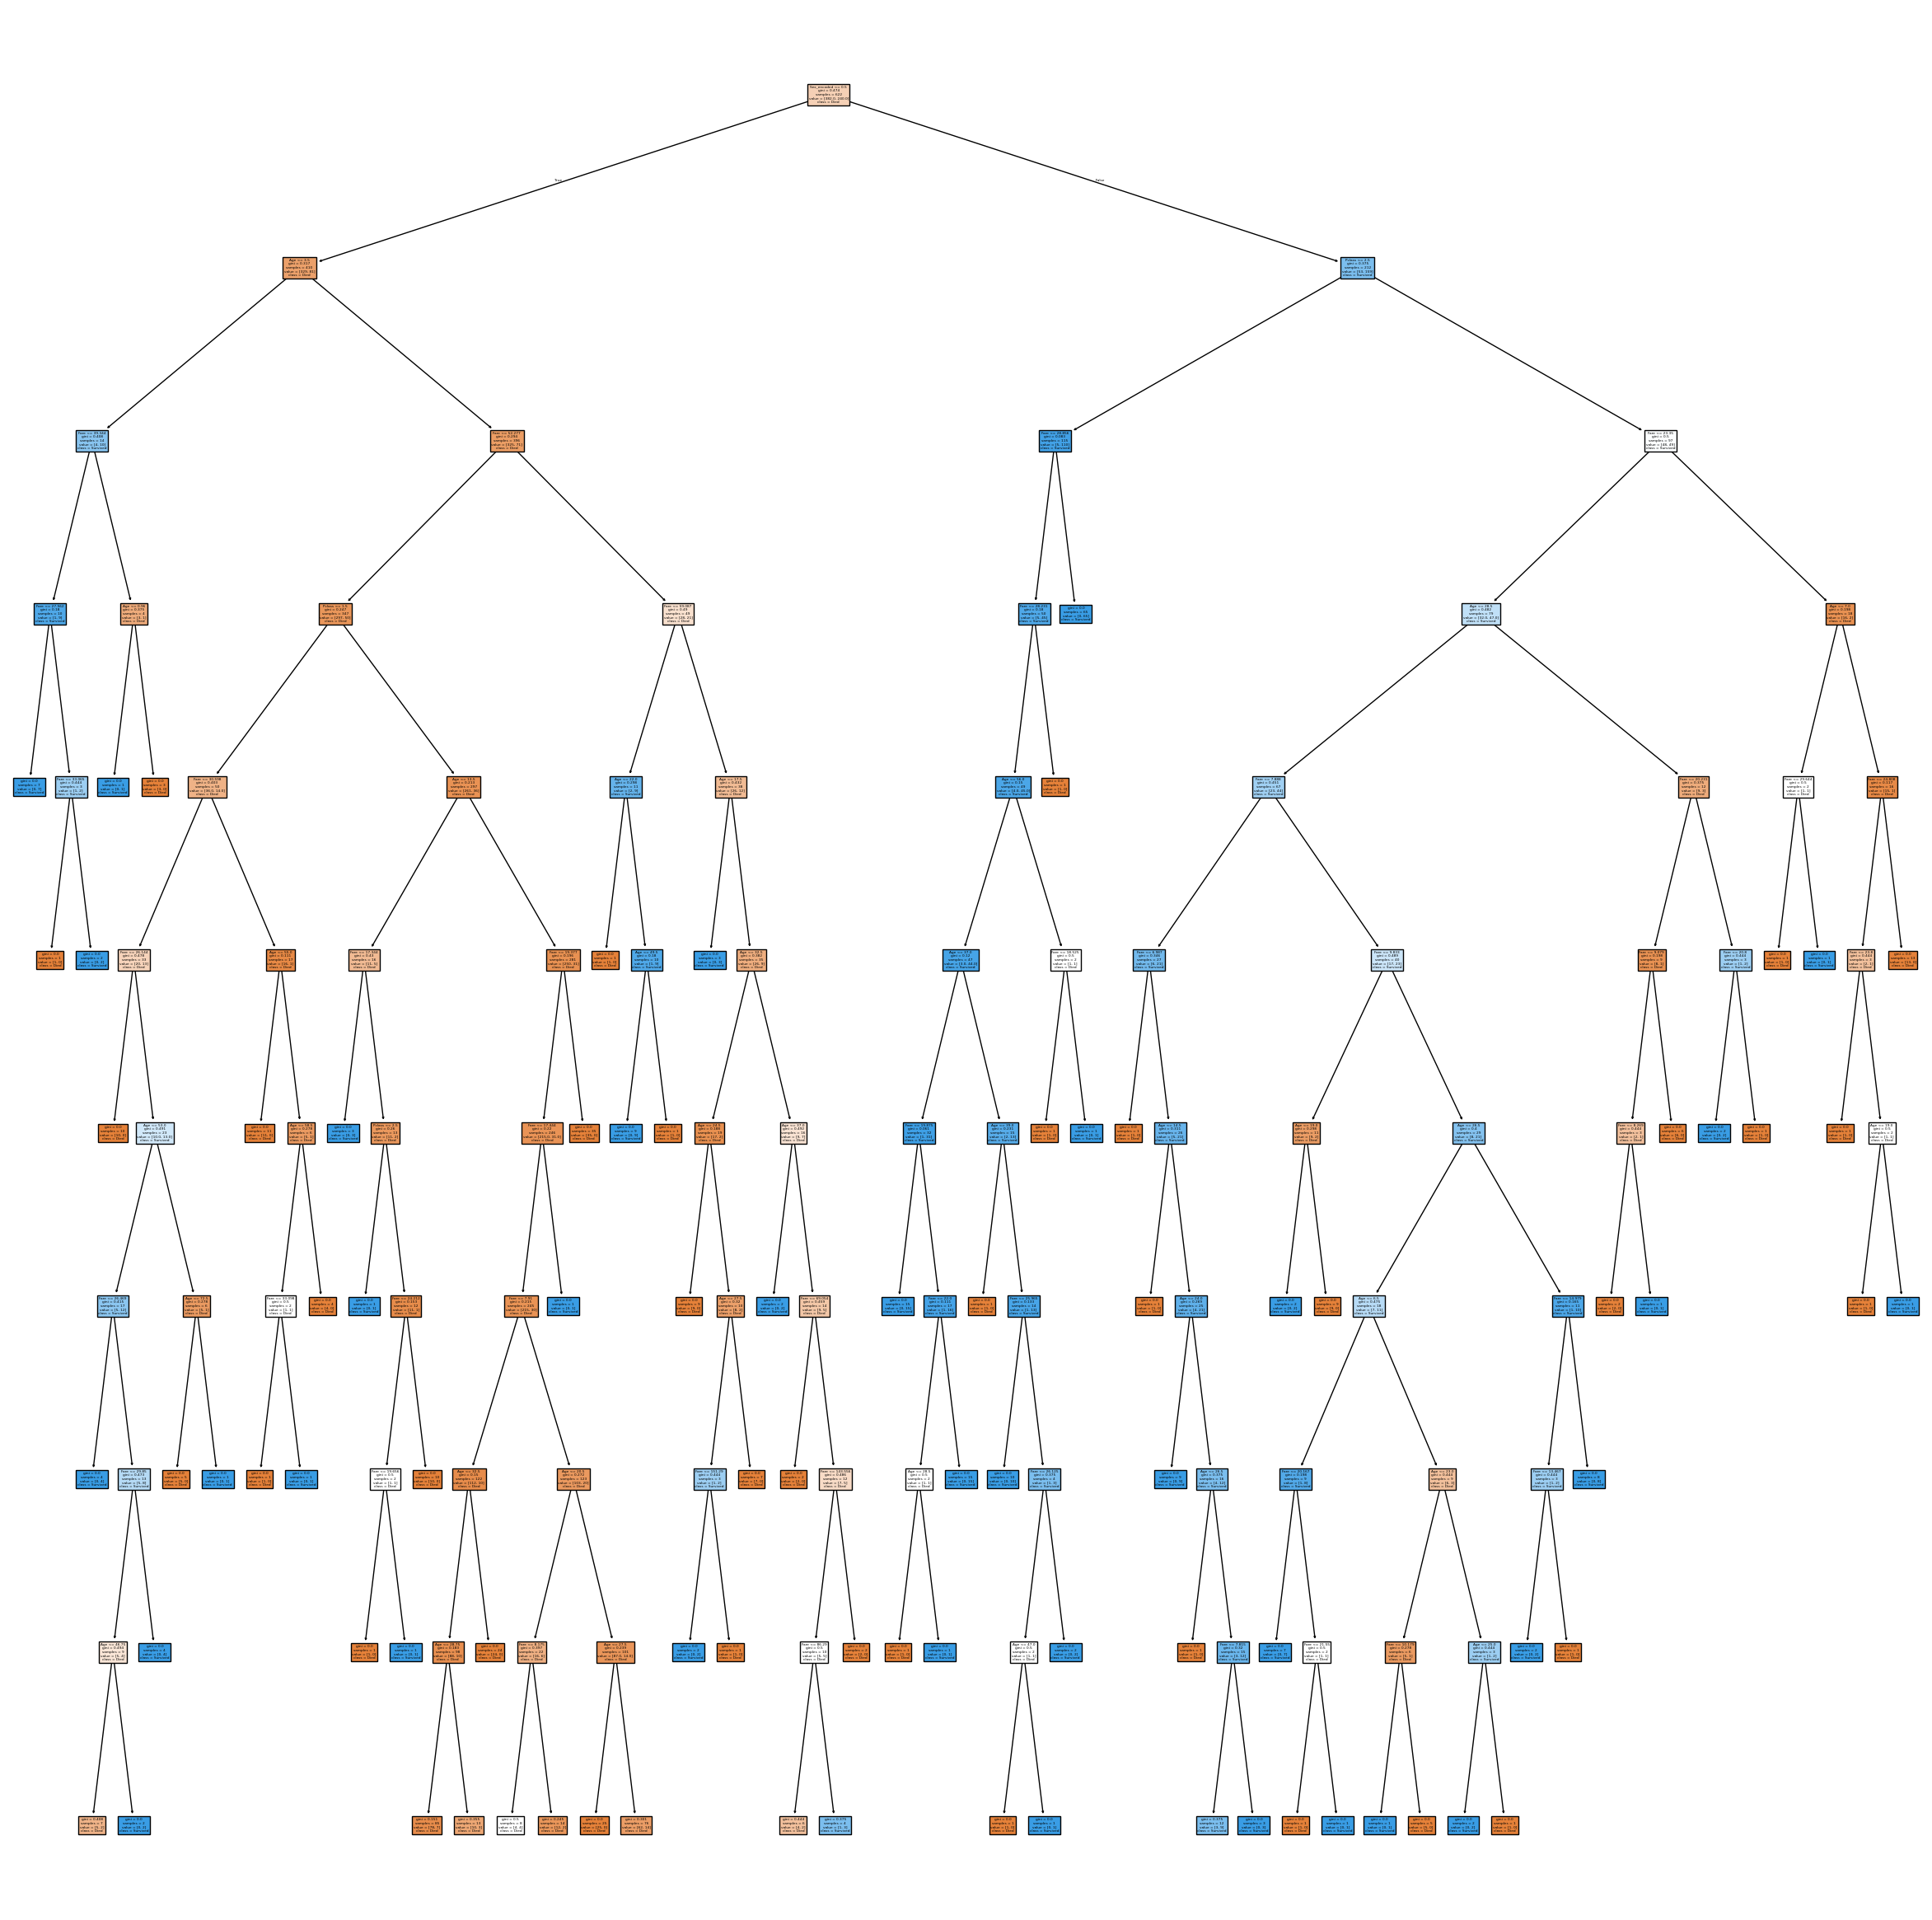

In [46]:
fig, ax = plt.subplots(figsize=(30,30))
plot_tree(clf_d10, feature_names=features, class_names=['Died', 'Survived'], filled=True, ax=ax)
plt.show()

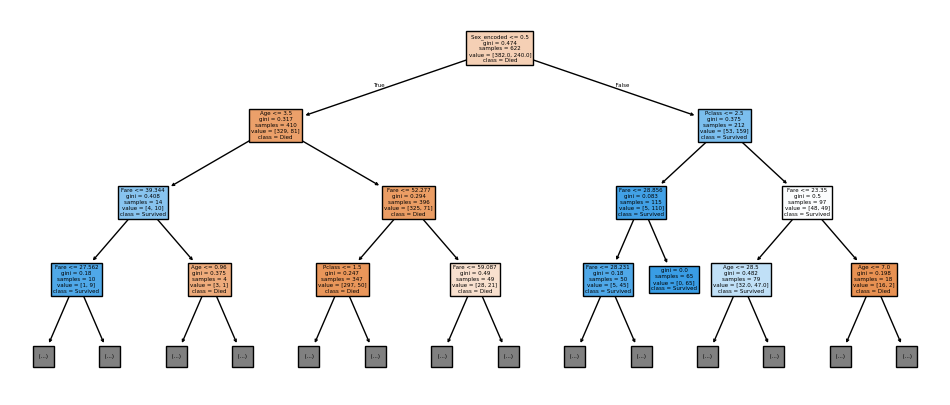

In [49]:
#max_depth=3 in plot_tree to truncate the display
fig, ax = plt.subplots(figsize=(12,5))
plot_tree(clf_d10, max_depth=3, feature_names=features,
          class_names=['Died','Survived'], filled=True, ax=ax)
plt.show()

### 7. **what does overfitting look like in a decision tree?**

- A decision tree overfits when `max_depth` is too large. At depth=10, the tree
grows too many nodes and learns the training data too specifically including
noise and outliers, rather than the underlying pattern.

Signs of overfitting:
- Visual: hundreds of nodes vs clean 3-node tree at depth=2
- Accuracy: depth=2 scored 80% vs depth=10 scored 78% on test data
- The deeper model memorised training data but generalised worse to unseen data

Solution: Control `max_depth`, use pruning, or move to ensemble methods
like Random Forest which average many trees to reduce overfitting.